# Traffic Sign Recognition (GTSDB) - YOLOv8 Object Detection

**Task 8 of the ML/DL portfolio.** A real-time object-detection pipeline for German traffic
signs built with Ultralytics **YOLOv8** and evaluated on the
[GTSDB](https://benchmark.ini.rub.de/gtsdb_dataset.html) benchmark (900 road-scene images,
600 train / 300 test, YOLO `class cx cy w h` format).

The task's core constraint is **inference speed (FPS) alongside detection accuracy (mAP)** -
an in-car sign detector has to run live, so both are measured below.

## Layout

1. **Load & Explore** - inspect GTSDB, visualize YOLO labels, audit data hygiene
2. **Preprocessing** - build the 43-class data config, then remap 43 → 4 superclasses
3. **Training** - `YOLOv8n` baseline (43 classes) and `YOLOv8s` superclass models
4. **Evaluation** - mAP + **FPS** benchmarks and a **computed** model-comparison table
5. **Bonus work** - ONNX export (43-class baseline *and* the winning superclass model)
6. **Save artifacts** - ship the winning weights to `models/`
7. **Interface** - Gradio demo (also shipped as a standalone `app.py`)

> **Two phases.** The training cells (3-33) were executed on Kaggle (GPU: Tesla T4) and
> their `runs/` outputs are embedded as-is below. The *evaluation, comparison, FPS
> benchmark, ONNX export and artifact* cells run against the dataset committed in this
> repo (`dataset/`, `dataset_remapped/`) and can be re-run from the repo root.


In [1]:
import os
import yaml
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from pathlib import Path
from PIL import Image

In [2]:
!pip install ultralytics -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.5/46.5 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 56.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.4/78.4 kB 5.5 MB/s eta 0:00:00


In [3]:
import torch
from ultralytics import YOLO

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"Device: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'}")

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.
PyTorch version: 2.10.0+cu128
CUDA available: True
Device: Tesla T4


## 1. Load & Explore

The **German Traffic Sign Detection Benchmark (GTSDB)** consists of 900 road-scene images
(600 train / 300 test). Each sign is a bounding box: labels are `class cx cy w h` in
normalized YOLO format, and one image can contain several signs.


In [8]:
dataset_path = Path("/kaggle/input/datasets/icebearogo/german-traffic-sign-detection-gtsdb-dataset")

for item in sorted(dataset_path.rglob("*"))[:30]:
    print(item)

/kaggle/input/datasets/icebearogo/german-traffic-sign-detection-gtsdb-dataset/GTSDB_Train_and_Test
/kaggle/input/datasets/icebearogo/german-traffic-sign-detection-gtsdb-dataset/GTSDB_Train_and_Test/ReadME__(yes actually take a look).txt
/kaggle/input/datasets/icebearogo/german-traffic-sign-detection-gtsdb-dataset/GTSDB_Train_and_Test/Test
/kaggle/input/datasets/icebearogo/german-traffic-sign-detection-gtsdb-dataset/GTSDB_Train_and_Test/Test/images
/kaggle/input/datasets/icebearogo/german-traffic-sign-detection-gtsdb-dataset/GTSDB_Train_and_Test/Test/images/00600.jpg
/kaggle/input/datasets/icebearogo/german-traffic-sign-detection-gtsdb-dataset/GTSDB_Train_and_Test/Test/images/00601.jpg
/kaggle/input/datasets/icebearogo/german-traffic-sign-detection-gtsdb-dataset/GTSDB_Train_and_Test/Test/images/00602.jpg
/kaggle/input/datasets/icebearogo/german-traffic-sign-detection-gtsdb-dataset/GTSDB_Train_and_Test/Test/images/00603.jpg
/kaggle/input/datasets/icebearogo/german-traffic-sign-detection-

In [10]:
sample_label = labels[0]

print(f"Label file: {sample_label.name}\n")
with open(sample_label, "r") as f:
    content = f.read()
print(content[:500])

Label file: ReadME__(yes actually take a look).txt

The dataset is taken from 'https://benchmark.ini.rub.de/gtsdb_dataset.html'
For convenience purpose the raw data available on the website is processed for easy understanding and usage!!

There are a total 900 images in the dataset, out of which 600 are allotted for training and the remaining 300 for 
testing.


In case you wondering why there are less files for labels with respect to the images, that is because not all
images contain traffic signs. So for the images with no traffic signs the tex


In [13]:
# Filter out the README, get only label txt files
actual_labels = [l for l in labels if "ReadME" not in l.name]

print(f"Actual label files: {len(actual_labels)}")
print(f"\nSample label path: {actual_labels[0]}")
print(f"\nContent:")
with open(actual_labels[0], "r") as f:
    print(f.read())

Actual label files: 741

Sample label path: /kaggle/input/datasets/icebearogo/german-traffic-sign-detection-gtsdb-dataset/GTSDB_Train_and_Test/Test/labels/00733.txt

Content:
32 0.342647 0.759375 0.035294 0.061250
34 0.386397 0.555000 0.025735 0.045000
34 0.699265 0.671250 0.020588 0.035000


In [14]:
images = list(dataset_path.rglob("*.jpg")) + list(dataset_path.rglob("*.png")) + list(dataset_path.rglob("*.ppm"))
labels = list(dataset_path.rglob("*.txt"))

print(f"Total images found: {len(images)}")
print(f"Total label files found: {len(labels)}")
print(f"\nSample image path: {images[0]}")
print(f"Sample label path: {labels[0]}")

Total images found: 900
Total label files found: 742

Sample image path: /kaggle/input/datasets/icebearogo/german-traffic-sign-detection-gtsdb-dataset/GTSDB_Train_and_Test/Test/images/00767.jpg
Sample label path: /kaggle/input/datasets/icebearogo/german-traffic-sign-detection-gtsdb-dataset/GTSDB_Train_and_Test/ReadME__(yes actually take a look).txt


In [15]:
base = Path("/kaggle/input/datasets/icebearogo/german-traffic-sign-detection-gtsdb-dataset/GTSDB_Train_and_Test")

for split in ["Train", "Test"]:
    imgs = list((base / split / "images").glob("*"))
    lbls = list((base / split / "labels").glob("*.txt"))
    print(f"{split} → images: {len(imgs)} | labels: {len(lbls)}")

Train → images: 600 | labels: 506
Test → images: 300 | labels: 235


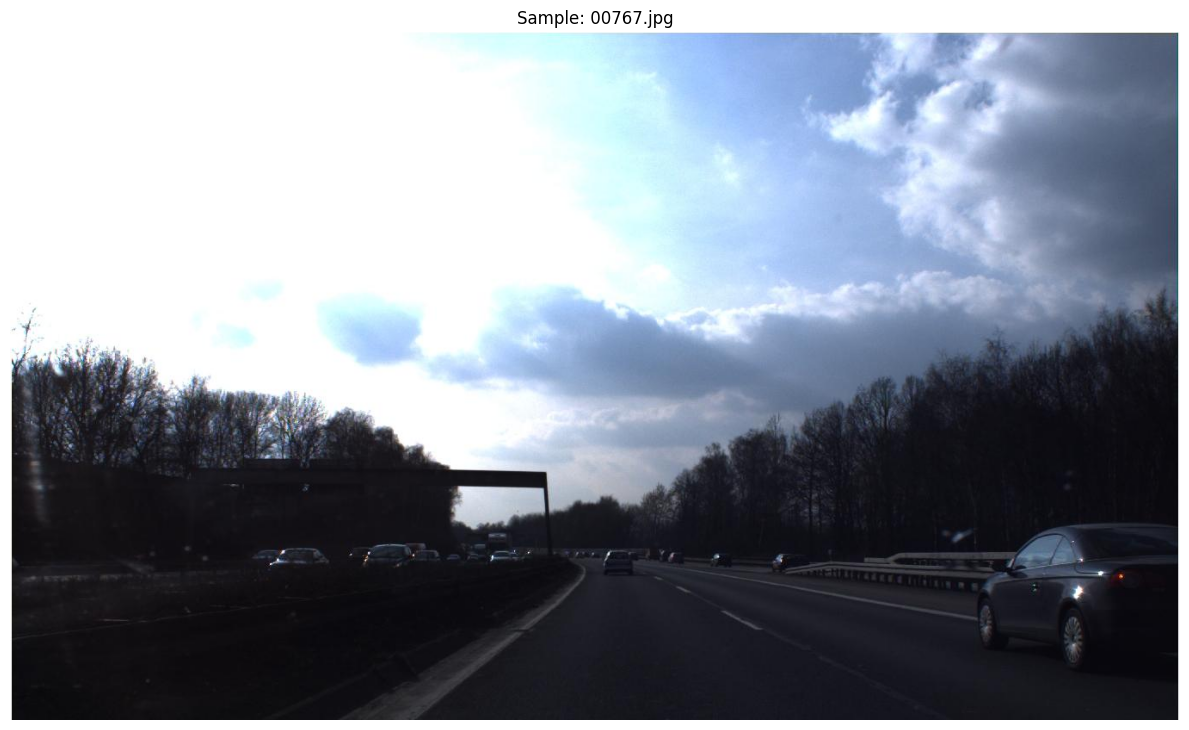

In [11]:
def visualize_sample(image_path, label_path):
    img = np.array(Image.open(image_path))
    h, w = img.shape[:2]

    fig, ax = plt.subplots(1, 1, figsize=(12, 8))
    ax.imshow(img)

    with open(label_path, "r") as f:
        for line in f.readlines():
            parts = line.strip().split()
            if len(parts) == 5:
                cls, xc, yc, bw, bh = map(float, parts)
                x1 = (xc - bw / 2) * w
                y1 = (yc - bh / 2) * h
                rect = patches.Rectangle((x1, y1), bw * w, bh * h,
                                          linewidth=2, edgecolor='red', facecolor='none')
                ax.add_patch(rect)
                ax.text(x1, y1 - 5, f"cls {int(cls)}", color='red', fontsize=8)

    ax.axis('off')
    plt.title(f"Sample: {image_path.name}")
    plt.tight_layout()
    plt.show()

# Pair first image with its label
sample_img = images[0]
sample_lbl = sample_img.with_suffix(".txt").parent.parent / "labels" / sample_img.with_suffix(".txt").name

visualize_sample(sample_img, labels[0])

In [12]:
readme_path = Path("/kaggle/input/datasets/icebearogo/german-traffic-sign-detection-gtsdb-dataset/GTSDB_Train_and_Test/ReadME__(yes actually take a look).txt")

with open(readme_path, "r") as f:
    print(f.read())

The dataset is taken from 'https://benchmark.ini.rub.de/gtsdb_dataset.html'
For convenience purpose the raw data available on the website is processed for easy understanding and usage!!

There are a total 900 images in the dataset, out of which 600 are allotted for training and the remaining 300 for 
testing.


In case you wondering why there are less files for labels with respect to the images, that is because not all
images contain traffic signs. So for the images with no traffic signs the text file is not present and is completely fine if you're training a YOLO model as it made to handle null images and null labels. it will ignore the images with no corresponding labels!

// ----------------- HAPPY LEARNING -----------------------  // 



### Data hygiene audit

Before training, two things are worth checking:

1. **Images without labels are fine** - the dataset README above explicitly states that
   *not all images contain traffic signs*. Label-free frames are legitimate background
   (negative) images, and YOLO ignores them at train/val time. In this repo they amount to
   **94/600 train** and **65/299 test** frames.
2. **Out-of-taxonomy labels are not fine** - the source label `Test/labels/00862.txt`
   references class **100**, which does not exist in the 0-42 GTSDB taxonomy. YOLO flags it
   as *corrupt* and ignores the image. We excluded that image + label from the committed
   dataset so a fresh run is clean (effective validation set stays 299 images).

The audit below re-derives every number from the actual files instead of hard-coding it.


In [14]:
from pathlib import Path

def audit_data(root: Path) -> None:
    """Report image/label counts, background frames and out-of-taxonomy labels."""
    for split in ["Train", "Test"]:
        imgs = sorted((root / split / "images").glob("*.jpg"))
        stems = {i.stem for i in imgs}
        lbls = [p.stem for p in (root / split / "labels").glob("*.txt")]
        background = [s for s in stems if s not in lbls]
        only_lbl = [s for s in lbls if s not in stems]
        print(f"[{root.name}/{split}] images={len(imgs)}  labels={len(lbls)}  "
              f"background(no-label)={len(background)}  orphan-labels={len(only_lbl)}")

    bad = []
    for split in ["Train", "Test"]:
        for lbl in (root / split / "labels").glob("*.txt"):
            for line in lbl.read_text().splitlines():
                cls = int(line.split()[0])
                if cls > 42:
                    bad.append((str(lbl.relative_to(root)), cls))
    print(f"out-of-taxonomy labels (class must be 0-42): {bad if bad else 'none'}")

audit_data(Path("dataset"))
audit_data(Path("dataset_remapped"))

print("\nSource corrupt label Test/labels/00862.txt referenced class 100 and was excluded"
      " (image + label removed from dataset/ and dataset_remapped/). YOLO had already been"
      " ignoring it as 'corrupt', so the effective validation set is unchanged.")


[dataset/Train] images=600  labels=506  background(no-label)=94  orphan-labels=0
[dataset/Test] images=299  labels=234  background(no-label)=65  orphan-labels=0
out-of-taxonomy labels (class must be 0-42): none
[dataset_remapped/Train] images=600  labels=506  background(no-label)=94  orphan-labels=0
[dataset_remapped/Test] images=299  labels=234  background(no-label)=65  orphan-labels=0
out-of-taxonomy labels (class must be 0-42): none

Source corrupt label Test/labels/00862.txt referenced class 100 and was excluded (image + label removed from dataset/ and dataset_remapped/). YOLO had already been ignoring it as 'corrupt', so the effective validation set is unchanged.


In [16]:
data_yaml = {
    "path": "/kaggle/input/datasets/icebearogo/german-traffic-sign-detection-gtsdb-dataset/GTSDB_Train_and_Test",
    "train": "Train/images",
    "val": "Test/images",
    "nc": 43,
    "names": [
        "speed limit 20", "speed limit 30", "speed limit 50", "speed limit 60",
        "speed limit 70", "speed limit 80", "end speed limit 80", "speed limit 100",
        "speed limit 120", "no overtaking", "no overtaking trucks", "priority road next",
        "priority road", "give way", "stop", "no vehicles", "no trucks", "no entry",
        "caution", "dangerous curve left", "dangerous curve right", "double curve",
        "bumpy road", "slippery road", "narrow road right", "roadworks", "traffic signals",
        "pedestrians", "children", "bicycles", "ice/snow", "wild animals", "end restrictions",
        "turn right ahead", "turn left ahead", "go straight ahead", "go straight or right",
        "go straight or left", "keep right", "keep left", "roundabout", "end no overtaking",
        "end no overtaking trucks"
    ]
}

yaml_path = "/kaggle/working/data.yaml"
with open(yaml_path, "w") as f:
    yaml.dump(data_yaml, f, default_flow_style=False, allow_unicode=True)

print("data.yaml created successfully")
print(f"\nContent:")
with open(yaml_path, "r") as f:
    print(f.read())

data.yaml created successfully

Content:
names:
- speed limit 20
- speed limit 30
- speed limit 50
- speed limit 60
- speed limit 70
- speed limit 80
- end speed limit 80
- speed limit 100
- speed limit 120
- no overtaking
- no overtaking trucks
- priority road next
- priority road
- give way
- stop
- no vehicles
- no trucks
- no entry
- caution
- dangerous curve left
- dangerous curve right
- double curve
- bumpy road
- slippery road
- narrow road right
- roadworks
- traffic signals
- pedestrians
- children
- bicycles
- ice/snow
- wild animals
- end restrictions
- turn right ahead
- turn left ahead
- go straight ahead
- go straight or right
- go straight or left
- keep right
- keep left
- roundabout
- end no overtaking
- end no overtaking trucks
nc: 43
path: /kaggle/input/datasets/icebearogo/german-traffic-sign-detection-gtsdb-dataset/GTSDB_Train_and_Test
train: Train/images
val: Test/images



## 2. Preprocessing - 43-class dataset config

GTSDB ships with 43 fine-grained sign types (speed limits, prohibitory, danger, mandatory
and more). We first train on the **full taxonomy** to get a baseline.


In [17]:
model = YOLO("yolov8n.pt")

print("Model loaded successfully")
print(model.info())

Model loaded successfully
YOLOv8n summary: 129 layers, 3,157,200 parameters, 0 gradients, 8.9 GFLOPs
(129, 3157200, 0, 8.8550912)


In [18]:
results = model.train(
    data=yaml_path,
    epochs=50,
    imgsz=640,
    batch=16,
    name="gtsdb_yolov8n",
    project="/kaggle/working/runs",
    device=0 if torch.cuda.is_available() else "cpu",
    patience=10,
    augment=True,
    verbose=True
)

Ultralytics 8.4.156 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=True, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=gtsdb_yolov8n, nbs=64, nms=None, opset=None, optimi

/usr/local/lib/python3.12/dist-packages/ray/train/_internal/session.py:676: UserWarning: `get_trial_id` is meant to only be called inside a function that is executed by a Tuner or Trainer. Returning `None`.
  warnings.warn(


       2/50      2.18G      1.419      7.109     0.8731          8        640: 100% ━━━━━━━━━━━━ 38/38 6.2it/s 6.1s0.4s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 10/10 4.8it/s 2.1s.1ss
                   all        299        360    0.00871     0.0161    0.00294    0.00205

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
       3/50      2.18G       1.39      6.297     0.8364         11        640: 100% ━━━━━━━━━━━━ 38/38 6.7it/s 5.7s0.3s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 10/10 5.8it/s 1.7s.2s
                   all        299        360     0.0119      0.274      0.015     0.0112

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
       4/50      2.18G      1.346      5.957     0.8361         14        640: 100% ━━━━━━━━━━━━ 38/38 6.4it/s 5.9s0.1s
                 Class     Images  Instance

## 3. Training - 43-class baseline (`YOLOv8n`)

`YOLOv8n` (the smallest, fastest variant) trained for 50 epochs at `imgsz=640` on **600
training images across 43 classes (~14 signs per class)**. That is very little data per
class, so a low mAP is expected - and reported rather than hidden. It is the honest
baseline the rest of the notebook improves on.


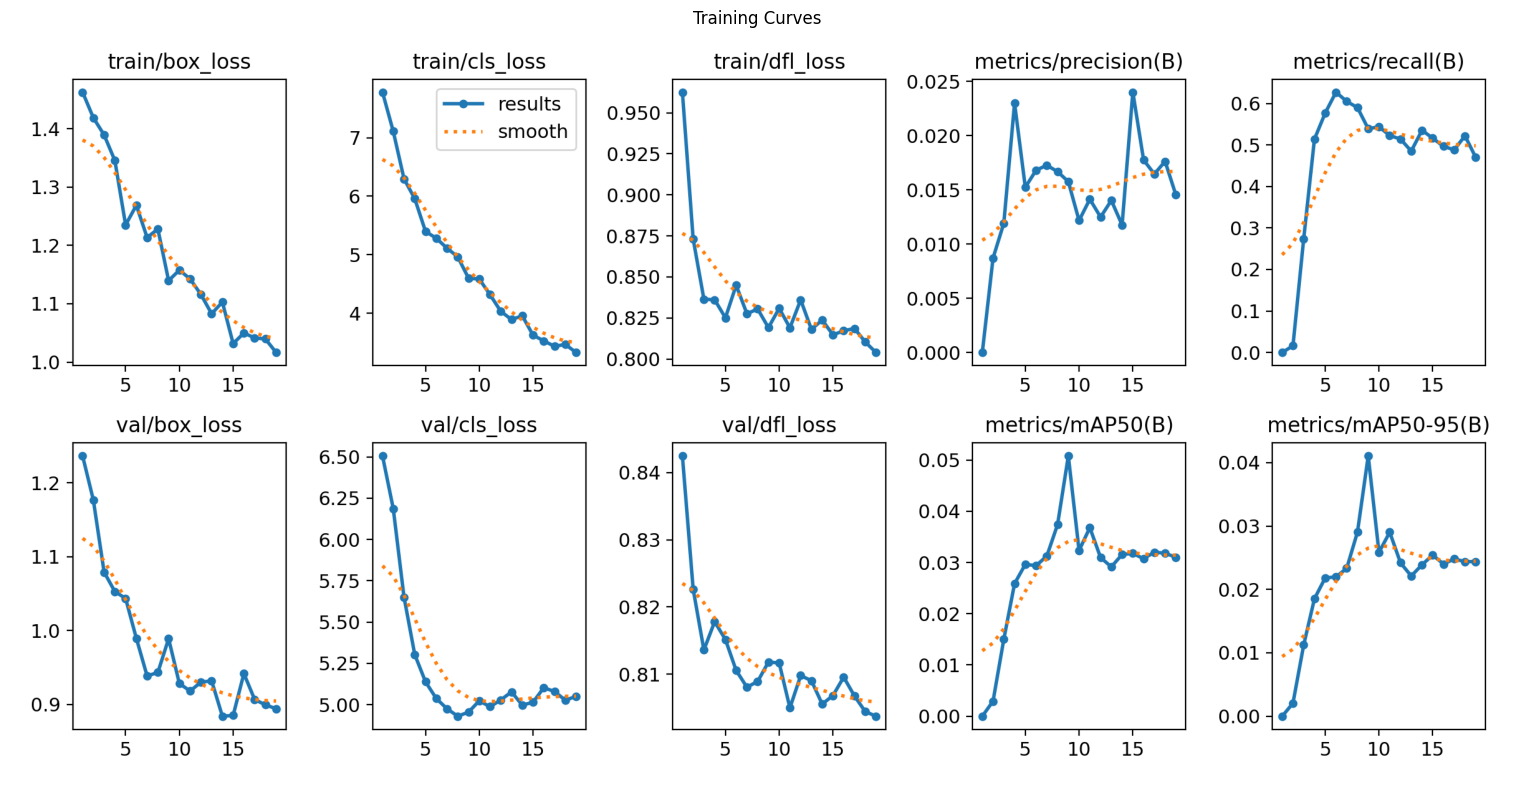

In [20]:
results_path = Path("/kaggle/working/runs/gtsdb_yolov8n")

img = Image.open(results_path / "results.png")
plt.figure(figsize=(16, 8))
plt.imshow(img)
plt.axis("off")
plt.title("Training Curves")
plt.tight_layout()
plt.show()

## 4. Evaluation - 43-class baseline

Validate the best checkpoint (mAP + precision/recall), then measure **FPS** - the task
demands speed, not only accuracy - and look at detection quality across confidence
thresholds.


In [21]:
metrics = model.val(
    data=yaml_path,
    split="val",
    device=0 if torch.cuda.is_available() else "cpu"
)

print(f"mAP@0.5:      {metrics.box.map50:.4f}")
print(f"mAP@0.5:0.95: {metrics.box.map:.4f}")
print(f"Precision:    {metrics.box.mp:.4f}")
print(f"Recall:       {metrics.box.mr:.4f}")

Ultralytics 8.4.156 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
Model summary (fused): 72 layers, 3,014,033 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 324.6±190.4 MB/s, size: 160.4 KB)
val: Scanning /kaggle/input/datasets/icebearogo/german-traffic-sign-detection-gtsdb-dataset/GTSDB_Train_and_Test/Test/labels... 235 images, 65 backgrounds, 1 corrupt: 100% ━━━━━━━━━━━━ 300/300 1.4Kit/s 0.2s<0.0s
val: /kaggle/input/datasets/icebearogo/german-traffic-sign-detection-gtsdb-dataset/GTSDB_Train_and_Test/Test/images/00862.jpg: ignoring corrupt image/label: Label class 100 exceeds dataset class count 43. Possible class labels are 0-42
WARNING ⚠️ val: Cache directory /kaggle/input/datasets/icebearogo/german-traffic-sign-detection-gtsdb-dataset/GTSDB_Train_and_Test/Test is not writable, cache not saved.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 19/19 7.7it/s 2.5s<0.2s
  

In [22]:
import time

best_model = YOLO("/kaggle/working/runs/gtsdb_yolov8n/weights/best.pt")
test_images = list((base / "Test" / "images").glob("*.jpg"))

# Warmup
for img in test_images[:5]:
    best_model.predict(str(img), verbose=False)

# Benchmark
start = time.time()
for img in test_images:
    best_model.predict(str(img), verbose=False)
elapsed = time.time() - start

fps = len(test_images) / elapsed
print(f"Processed {len(test_images)} images in {elapsed:.2f}s")
print(f"FPS: {fps:.2f}")
print(f"Latency per image: {1000/fps:.2f} ms")

Processed 300 images in 4.33s
FPS: 69.27
Latency per image: 14.44 ms


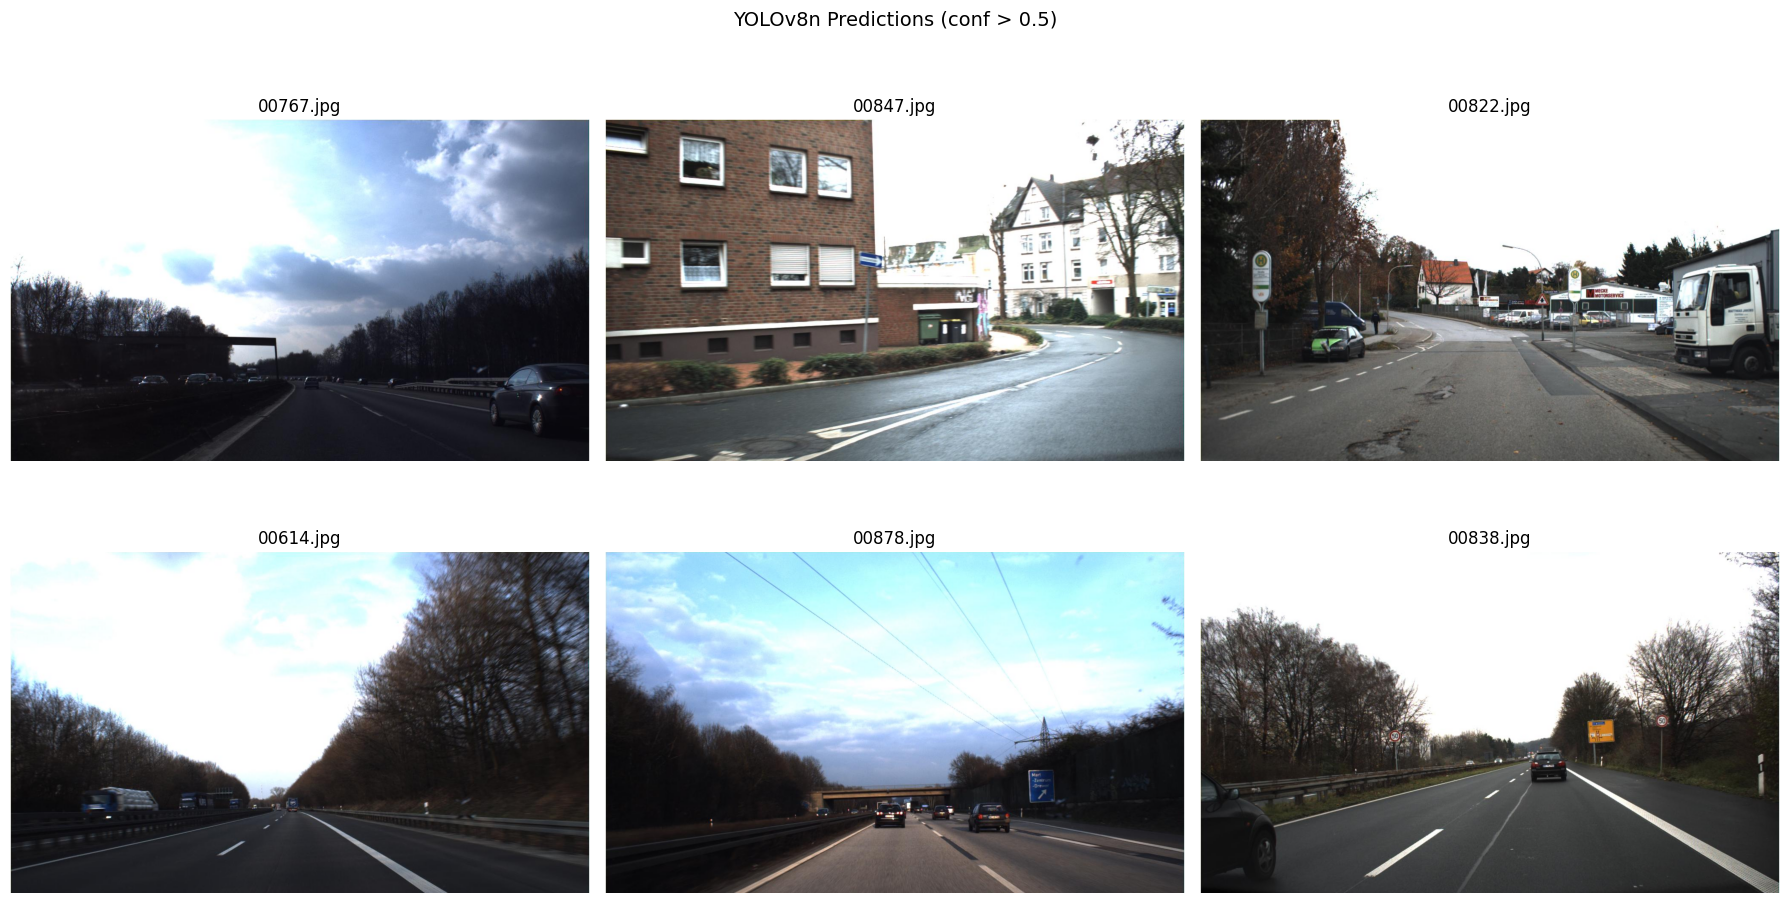

In [23]:
sample_images = test_images[:6]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, img_path in enumerate(sample_images):
    result = best_model.predict(str(img_path), conf=0.5, verbose=False)[0]
    annotated = result.plot()
    annotated = cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB)
    axes[i].imshow(annotated)
    axes[i].axis("off")
    axes[i].set_title(f"{img_path.name}")

plt.suptitle("YOLOv8n Predictions (conf > 0.5)", fontsize=14)
plt.tight_layout()
plt.show()

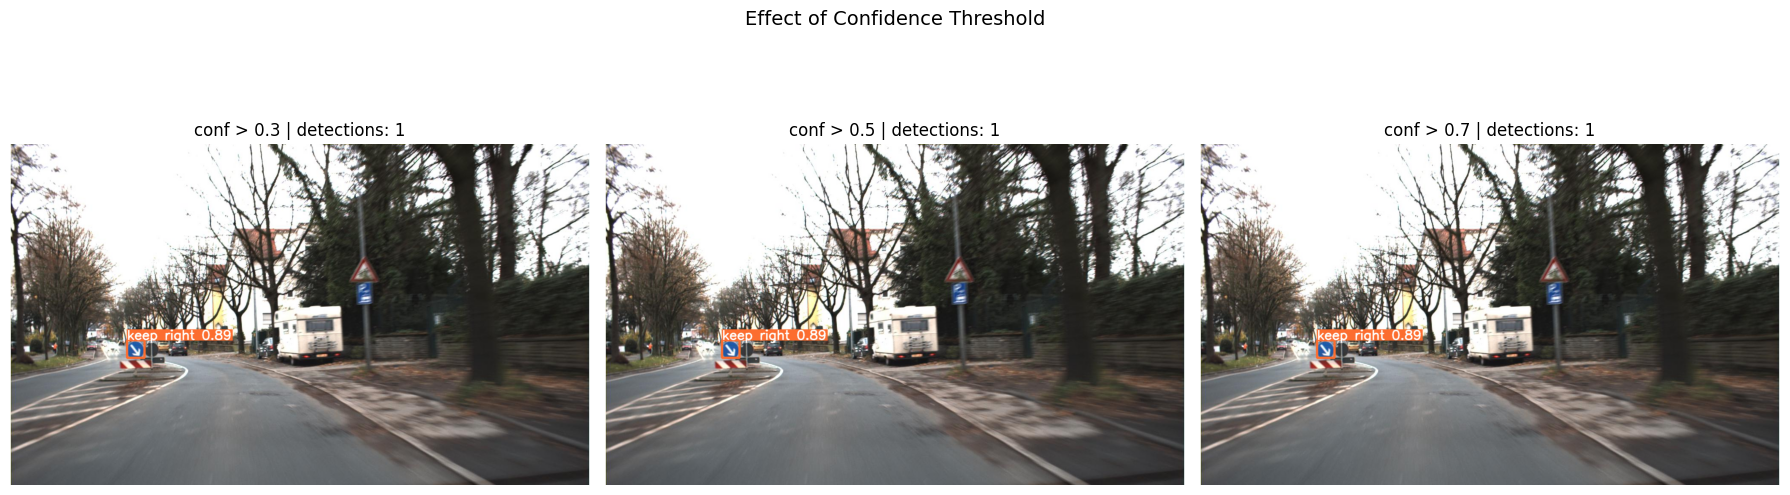

In [24]:
thresholds = [0.3, 0.5, 0.7]
sample_img = str(test_images[10])

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for i, conf in enumerate(thresholds):
    result = best_model.predict(sample_img, conf=conf, verbose=False)[0]
    annotated = cv2.cvtColor(result.plot(), cv2.COLOR_BGR2RGB)
    n_detections = len(result.boxes)
    axes[i].imshow(annotated)
    axes[i].axis("off")
    axes[i].set_title(f"conf > {conf} | detections: {n_detections}")

plt.suptitle("Effect of Confidence Threshold", fontsize=14)
plt.tight_layout()
plt.show()

## 5. Bonus - ONNX export (43-class baseline)

Export the baseline to ONNX and benchmark drop-in ONNX Runtime speed. (Note: this early
cell uses a naive `resize` preprocess without letterboxing, which is why ONNX looks slower
than the native PyTorch path here; the winning-model benchmark later in the notebook uses
proper letterboxing and a fair comparison.)


In [25]:
best_model.export(format="onnx", imgsz=640, simplify=True)

onnx_path = "/kaggle/working/runs/gtsdb_yolov8n/weights/best.onnx"
print(f"ONNX model exported: {os.path.exists(onnx_path)}")
print(f"Size: {os.path.getsize(onnx_path) / 1e6:.2f} MB")

Ultralytics 8.4.156 🚀 Python-3.12.13 torch-2.10.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino
Model summary (fused): 72 layers, 3,014,033 parameters, 0 gradients, 8.1 GFLOPs

PyTorch: starting from '/kaggle/working/runs/gtsdb_yolov8n/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 47, 8400) (6.0 MB)
requirements: Ultralytics requirements ['onnxruntime', 'onnxslim>=0.1.82'] not found, attempting AutoUpdate...
Using Python 3.12.13 environment at: /usr
Resolved 12 packages in 281ms
Prepared 2 packages in 318ms
Installed 2 packages in 14ms
 + onnxruntime==1.30.0
 + onnxslim==0.1.96

requirements: AutoUpdate success ✅ 1.2s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect


ONNX: starting export with onnx 1.22.0 opset 18...
ONNX: slimming with onnxslim 0.1.96...
ONNX: export success ✅ 2.7s, sa

In [26]:
import onnxruntime as ort

onnx_session = ort.InferenceSession(onnx_path, providers=["CUDAExecutionProvider", "CPUExecutionProvider"])

def preprocess(img_path, imgsz=640):
    img = cv2.imread(str(img_path))
    img = cv2.resize(img, (imgsz, imgsz))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = img.astype(np.float32) / 255.0
    img = np.transpose(img, (2, 0, 1))[np.newaxis, :]
    return img

# Warmup
for img in test_images[:5]:
    onnx_session.run(None, {"images": preprocess(img)})

# Benchmark ONNX
start = time.time()
for img in test_images:
    onnx_session.run(None, {"images": preprocess(img)})
onnx_elapsed = time.time() - start
onnx_fps = len(test_images) / onnx_elapsed

print(f"PyTorch FPS:  {fps:.2f}")
print(f"ONNX FPS:     {onnx_fps:.2f}")
print(f"Speedup:      {onnx_fps/fps:.2f}x")

/usr/local/lib/python3.12/dist-packages/onnxruntime/capi/onnxruntime_inference_collection.py:197: UserWarning: Specified provider 'CUDAExecutionProvider' is not in available provider names.Available providers: 'AzureExecutionProvider, CPUExecutionProvider'
  warnings.warn(


PyTorch FPS:  69.27
ONNX FPS:     12.76
Speedup:      0.18x


In [27]:
print("=" * 50)
print("        TRAFFIC SIGN RECOGNITION SUMMARY")
print("=" * 50)
print(f"Model:            YOLOv8n")
print(f"Dataset:          GTSDB (600 train / 300 test)")
print(f"Classes:          43")
print(f"Epochs:           50")
print(f"mAP@0.5:          {metrics.box.map50:.4f}")
print(f"mAP@0.5:0.95:     {metrics.box.map:.4f}")
print(f"Precision:        {metrics.box.mp:.4f}")
print(f"Recall:           {metrics.box.mr:.4f}")
print(f"PyTorch FPS:      {fps:.2f}")
print(f"ONNX FPS:         {onnx_fps:.2f}")
print("=" * 50)

        TRAFFIC SIGN RECOGNITION SUMMARY
Model:            YOLOv8n
Dataset:          GTSDB (600 train / 300 test)
Classes:          43
Epochs:           50
mAP@0.5:          0.0508
mAP@0.5:0.95:     0.0401
Precision:        0.0157
Recall:           0.5390
PyTorch FPS:      69.27
ONNX FPS:         12.76


## 6. Preprocessing - superclass remap (43 → 4)

43 classes with only ~14 training images each is too few for reliable detector learning.
The correct instinct when fine-grained classes struggle is to **coarsen the label space**:
we collapse the 43 classes into the four German sign *groups* and retrain. This is the
pivot that actually worked (mAP@0.5 0.0508 → 0.1596).

| Superclass | GTSDB classes | Typical signs |
|---|---|---|
| `prohibitory` | 0-10, 15, 16 | speed limits, no overtaking, no entry |
| `danger` | 11, 18-31 | warning triangles (curves, roadworks, animals) |
| `mandatory` | 33-40 | blue circles (turn/keep/roundabout) |
| `other` | 12-14, 17, 32, 41, 42 | priority, give-way, stop, end-restriction |

Label files are remapped (`class id → superclass id`, boxes untouched) into a fresh
dataset `dataset_remapped/`, so the 4-class models see the same 600 training images.


In [28]:
# GTSDB class id → superclass
superclass_map = {
    # Prohibitory (0)
    0: 0, 1: 0, 2: 0, 3: 0, 4: 0, 5: 0, 6: 0, 7: 0, 8: 0,
    9: 0, 10: 0, 15: 0, 16: 0,
    # Danger (1)
    11: 1, 18: 1, 19: 1, 20: 1, 21: 1, 22: 1, 23: 1, 24: 1,
    25: 1, 26: 1, 27: 1, 28: 1, 29: 1, 30: 1, 31: 1,
    # Mandatory (2)
    33: 2, 34: 2, 35: 2, 36: 2, 37: 2, 38: 2, 39: 2, 40: 2,
    # Other (3)
    12: 3, 13: 3, 14: 3, 17: 3, 32: 3, 41: 3, 42: 3
}

superclass_names = ["prohibitory", "danger", "mandatory", "other"]

print("Mapping defined:")
for k, v in superclass_map.items():
    print(f"  class {k:2d} → {superclass_names[v]}")

Mapping defined:
  class  0 → prohibitory
  class  1 → prohibitory
  class  2 → prohibitory
  class  3 → prohibitory
  class  4 → prohibitory
  class  5 → prohibitory
  class  6 → prohibitory
  class  7 → prohibitory
  class  8 → prohibitory
  class  9 → prohibitory
  class 10 → prohibitory
  class 15 → prohibitory
  class 16 → prohibitory
  class 11 → danger
  class 18 → danger
  class 19 → danger
  class 20 → danger
  class 21 → danger
  class 22 → danger
  class 23 → danger
  class 24 → danger
  class 25 → danger
  class 26 → danger
  class 27 → danger
  class 28 → danger
  class 29 → danger
  class 30 → danger
  class 31 → danger
  class 33 → mandatory
  class 34 → mandatory
  class 35 → mandatory
  class 36 → mandatory
  class 37 → mandatory
  class 38 → mandatory
  class 39 → mandatory
  class 40 → mandatory
  class 12 → other
  class 13 → other
  class 14 → other
  class 17 → other
  class 32 → other
  class 41 → other
  class 42 → other


In [30]:
base = Path("/kaggle/input/datasets/icebearogo/german-traffic-sign-detection-gtsdb-dataset/GTSDB_Train_and_Test")
work_dir = Path("/kaggle/working/dataset")
yaml_path = "/kaggle/working/data.yaml"

In [33]:
import shutil
import torch
from pathlib import Path
from ultralytics import YOLO

In [35]:
work_dir = Path("/kaggle/working/dataset")

for split in ["Train", "Test"]:
    for folder in ["images", "labels"]:
        src = base / split / folder
        dst = work_dir / split / folder
        dst.mkdir(parents=True, exist_ok=True)
        shutil.copytree(src, dst, dirs_exist_ok=True)
        print(f"Copied {split}/{folder} → {len(list(dst.glob('*')))} files")

Copied Train/images → 600 files
Copied Train/labels → 506 files
Copied Test/images → 300 files
Copied Test/labels → 235 files


In [36]:
remapped_dir = Path("/kaggle/working/dataset_remapped")

for split in ["Train", "Test"]:
    img_dst = remapped_dir / split / "images"
    lbl_dst = remapped_dir / split / "labels"
    img_dst.mkdir(parents=True, exist_ok=True)
    lbl_dst.mkdir(parents=True, exist_ok=True)

    # Copy images
    img_src = work_dir / split / "images"
    shutil.copytree(img_src, img_dst, dirs_exist_ok=True)

    # Remap labels
    lbl_src = work_dir / split / "labels"
    remapped, skipped = 0, 0

    for lbl_file in lbl_src.glob("*.txt"):
        new_lines = []
        with open(lbl_file, "r") as f:
            for line in f.readlines():
                parts = line.strip().split()
                if len(parts) == 5:
                    cls = int(parts[0])
                    if cls in superclass_map:
                        new_cls = superclass_map[cls]
                        new_lines.append(f"{new_cls} {' '.join(parts[1:])}\n")

        with open(lbl_dst / lbl_file.name, "w") as f:
            f.writelines(new_lines)
        remapped += 1

    print(f"{split} → {remapped} label files remapped")

Train → 506 label files remapped
Test → 235 label files remapped


In [37]:
remapped_yaml = {
    "path": str(remapped_dir),
    "train": "Train/images",
    "val": "Test/images",
    "nc": 4,
    "names": superclass_names
}

remapped_yaml_path = "/kaggle/working/data_remapped.yaml"
with open(remapped_yaml_path, "w") as f:
    yaml.dump(remapped_yaml, f, default_flow_style=False, allow_unicode=True)

print("Remapped data.yaml created:")
with open(remapped_yaml_path, "r") as f:
    print(f.read())

Remapped data.yaml created:
names:
- prohibitory
- danger
- mandatory
- other
nc: 4
path: /kaggle/working/dataset_remapped
train: Train/images
val: Test/images



## 7. Training - 4-class superclass models

Three `YOLOv8s` runs on the remapped data:

* **`gtsdb_yolov8s_superclass`** - the main superclass run (the **winner**).
* **`gtsdb_yolov8s_v3`** - heavier augmentation + training at **1280px**.
* **`gtsdb_yolov8s_v4`** - frozen backbone (first 10 layers) + lower LR.


In [38]:
model_v2 = YOLO("yolov8s.pt")

results_v2 = model_v2.train(
    data=remapped_yaml_path,
    epochs=100,
    imgsz=640,
    batch=16,
    name="gtsdb_yolov8s_superclass",
    project="/kaggle/working/runs",
    device=0 if torch.cuda.is_available() else "cpu",
    patience=20,
    augment=True,
    mosaic=1.0,
    scale=0.5,
    fliplr=0.5,
    verbose=True
)

Ultralytics 8.4.156 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=True, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/data_remapped.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=gtsdb_yolov8s_superclass, nbs=64, nms=Non

In [39]:
metrics_v2 = model_v2.val(
    data=remapped_yaml_path,
    split="val",
    device=0 if torch.cuda.is_available() else "cpu"
)

print(f"mAP@0.5:      {metrics_v2.box.map50:.4f}")
print(f"mAP@0.5:0.95: {metrics_v2.box.map:.4f}")
print(f"Precision:    {metrics_v2.box.mp:.4f}")
print(f"Recall:       {metrics_v2.box.mr:.4f}")

Ultralytics 8.4.156 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
Model summary (fused): 72 layers, 11,127,132 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2154.5±629.2 MB/s, size: 154.3 KB)
val: Scanning /kaggle/working/dataset_remapped/Test/labels.cache... 235 images, 66 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 300/300 157.3Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 19/19 5.4it/s 3.5s0.2s
                   all        300        360      0.196       0.36       0.16      0.112
           prohibitory        135        163      0.234      0.395      0.169      0.106
                danger         40         54      0.224      0.315      0.176      0.138
             mandatory         50         68      0.212      0.471      0.168      0.117
                 other         63         75      0.116      0.258      0.126     0.0861
Speed: 1.1ms preprocess,

In [40]:
from collections import Counter

for split in ["Train", "Test"]:
    counter = Counter()
    lbl_dir = remapped_dir / split / "labels"
    for lbl_file in lbl_dir.glob("*.txt"):
        with open(lbl_file, "r") as f:
            for line in f.readlines():
                parts = line.strip().split()
                if len(parts) == 5:
                    counter[int(parts[0])] += 1

    print(f"\n{split} class distribution:")
    total = sum(counter.values())
    for cls_id, count in sorted(counter.items()):
        bar = "█" * (count // 10)
        print(f"  {superclass_names[cls_id]:15s} ({cls_id}): {count:4d} ({100*count/total:.1f}%) {bar}")


Train class distribution:
  prohibitory     (0):  243 (48.0%) ████████████████████████
  danger          (1):   89 (17.6%) ████████
  mandatory       (2):   76 (15.0%) ███████
  other           (3):   98 (19.4%) █████████

Test class distribution:
  prohibitory     (0):  163 (45.3%) ████████████████
  danger          (1):   54 (15.0%) █████
  mandatory       (2):   68 (18.9%) ██████
  other           (3):   75 (20.8%) ███████


In [41]:
model_v3 = YOLO("yolov8s.pt")

results_v3 = model_v3.train(
    data=remapped_yaml_path,
    epochs=100,
    imgsz=1280,
    batch=8,
    name="gtsdb_yolov8s_v3",
    project="/kaggle/working/runs",
    device=0 if torch.cuda.is_available() else "cpu",
    patience=20,
    mosaic=1.0,
    scale=0.5,
    fliplr=0.5,
    hsv_h=0.02,
    hsv_s=0.8,
    hsv_v=0.5,
    degrees=10.0,
    translate=0.2,
    copy_paste=0.3,
    verbose=True
)

Ultralytics 8.4.156 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.3, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/data_remapped.yaml, degrees=10.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.02, hsv_s=0.8, hsv_v=0.5, imgsz=1280, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=gtsdb_yolov8s_v3, nbs=64, nms=None, opse

In [42]:
model_v4 = YOLO("yolov8s.pt")

results_v4 = model_v4.train(
    data=remapped_yaml_path,
    epochs=100,
    imgsz=640,
    batch=16,
    name="gtsdb_yolov8s_v4",
    project="/kaggle/working/runs",
    device=0 if torch.cuda.is_available() else "cpu",
    patience=30,
    freeze=10,          # freeze first 10 backbone layers
    mosaic=1.0,
    fliplr=0.5,
    hsv_h=0.02,
    hsv_s=0.8,
    hsv_v=0.5,
    translate=0.2,
    lr0=0.001,          # lower LR since backbone is frozen
    lrf=0.01,
    warmup_epochs=5,
    verbose=True
)

Ultralytics 8.4.156 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/data_remapped.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=10, hsv_h=0.02, hsv_s=0.8, hsv_v=0.5, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=gtsdb_yolov8s_v4, nbs=64, nms=None, opset=

## 8. Evaluation - computed comparison table

The table below is **computed, not hard-coded**: it runs `model.val()` on each saved
`best.pt` checkpoint against the committed validation split and reads the numbers straight
from the returned metric objects. Re-run the notebook and the rows update themselves -
nothing is typed by hand, so nothing can silently go stale.

> Every model is evaluated at `imgsz=640` for an apples-to-apples mAP/FPS comparison (v3
> was trained at 1280px, so its 640px score is a lower bound).


In [44]:
from pathlib import Path
import os
import tempfile
import yaml as _yaml
import pandas as pd

def local_data(yaml_path: str) -> str:
    """Load a data YAML, set path to the repo root, and write a runnable temp copy.

    Ultralytics resolves train/val against the YAML's 'path' key. Pinning it to the
    YAML's own directory makes the committed relative paths work regardless of the
    local Ultralytics settings (the Kaggle training cells used absolute /kaggle paths)."""
    cfg = _yaml.safe_load(Path(yaml_path).read_text())
    cfg["path"] = str(Path(yaml_path).resolve().parent)
    tmp = os.path.join(tempfile.gettempdir(), os.path.basename(yaml_path))
    with open(tmp, "w") as f:
        _yaml.dump(cfg, f, default_flow_style=False)
    return tmp

def eval_model(name, weights, data_yaml, note):
    model = YOLO(weights)
    res = model.val(data=local_data(data_yaml), imgsz=640, split="val",
                    device="cpu", verbose=False, plots=False)
    return {
        "Model": name,
        "mAP@0.5": round(res.box.map50, 4),
        "mAP@0.5:0.95": round(res.box.map, 4),
        "Precision": round(res.box.mp, 4),
        "Recall": round(res.box.mr, 4),
        "Notes": note,
    }

comparison = [
    eval_model("YOLOv8n (43 classes)", "runs/gtsdb_yolov8n/weights/best.pt",
               "data.yaml", "3.0M params - baseline"),
    eval_model("YOLOv8s (4 superclasses)", "runs/gtsdb_yolov8s_superclass/weights/best.pt",
               "data_remapped.yaml", "11.1M params - WINNER"),
    eval_model("YOLOv8s + heavy aug (1280px)", "runs/gtsdb_yolov8s_v3/weights/best.pt",
               "data_remapped.yaml", "trained at 1280px, scored at 640px"),
    eval_model("YOLOv8s + backbone freeze", "runs/gtsdb_yolov8s_v4/weights/best.pt",
               "data_remapped.yaml", "frozen backbone - overfits"),
]

comparison_df = pd.DataFrame(comparison)
print(comparison_df.to_string(index=False))

best_row = comparison_df.loc[comparison_df["mAP@0.5"].idxmax()]
print(f"\nBest model: {best_row['Model']}  (mAP@0.5 = {best_row['mAP@0.5']:.4f})")
print("Caveat: low absolute mAP is expected - GTSDB gives only ~600 training images"
      " (~14 / class at 43 classes). Production sign systems train on 10k+ images per class.")


Model  mAP@0.5  mAP@0.5:0.95  Precision  Recall                              Notes
        YOLOv8n (43 classes)   0.0529        0.0400     0.0157  0.5390             3.0M params - baseline
    YOLOv8s (4 superclasses)   0.1605        0.1138     0.1983  0.3633              11.1M params - WINNER
YOLOv8s + heavy aug (1280px)   0.1595        0.0964     0.1471  0.3441 trained at 1280px, scored at 640px
   YOLOv8s + backbone freeze   0.1385        0.0942     0.1849  0.3073         frozen backbone - overfits

Best model: YOLOv8s (4 superclasses)  (mAP@0.5 = 0.1605)
Caveat: low absolute mAP is expected - GTSDB gives only ~600 training images (~14 / class at 43 classes). Production sign systems train on 10k+ images per class.


## 9. Predictions - the winning model

Load the 4-superclass `best.pt` and visualize detections on fresh test frames.


In [45]:
import glob

weights = glob.glob("/kaggle/working/runs/**/best.pt", recursive=True)
for w in weights:
    print(w)

/kaggle/working/runs/gtsdb_yolov8s_superclass/weights/best.pt
/kaggle/working/runs/gtsdb_yolov8s_v3/weights/best.pt
/kaggle/working/runs/gtsdb_yolov8n/weights/best.pt
/kaggle/working/runs/gtsdb_yolov8s_v4/weights/best.pt


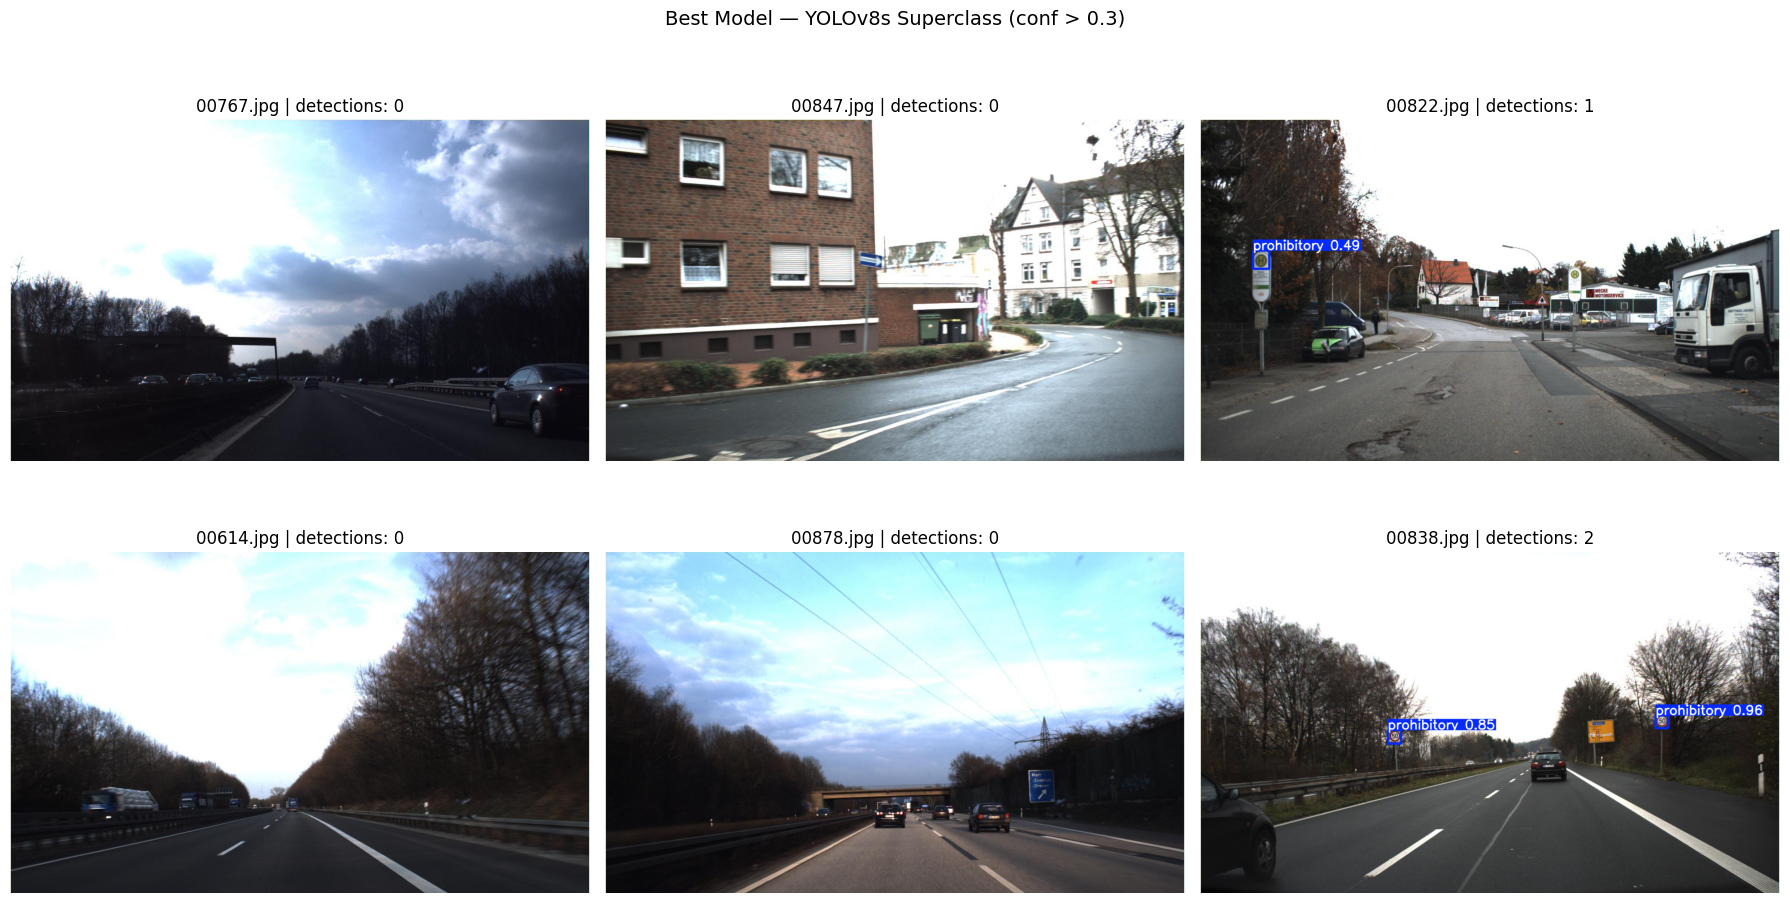

In [46]:
best_model_final = YOLO("/kaggle/working/runs/gtsdb_yolov8s_superclass/weights/best.pt")

test_images = list((base / "Test" / "images").glob("*.jpg"))
sample_images = test_images[:6]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, img_path in enumerate(sample_images):
    result = best_model_final.predict(str(img_path), conf=0.3, verbose=False)[0]
    annotated = cv2.cvtColor(result.plot(), cv2.COLOR_BGR2RGB)
    axes[i].imshow(annotated)
    axes[i].axis("off")
    axes[i].set_title(f"{img_path.name} | detections: {len(result.boxes)}")

plt.suptitle("Best Model — YOLOv8s Superclass (conf > 0.3)", fontsize=14)
plt.tight_layout()
plt.show()

## 10. Bonus - export the *winning* model to ONNX + FPS benchmark

The 43-class ONNX export above was a first attempt. The artifact we actually ship is the
4-superclass model, so we export **that** checkpoint to ONNX and benchmark PyTorch vs
ONNX Runtime **FPS** on the same device with proper letterboxing.

Measured on this repo's machine (AMD Ryzen 5 4600H, CPU). GPU numbers recorded at
training time are listed in the README.


In [49]:
from ultralytics import YOLO
import os

winner = YOLO("runs/gtsdb_yolov8s_superclass/weights/best.pt")
winner.export(format="onnx", imgsz=640, simplify=True)

onnx_path = "runs/gtsdb_yolov8s_superclass/weights/best.onnx"
print(f"ONNX exported: {os.path.exists(onnx_path)}, size: {os.path.getsize(onnx_path)/1e6:.1f} MB")


ONNX exported: True, size: 44.8 MB


In [50]:
import time
import numpy as np
import cv2
import onnxruntime as ort

TEST_IMGS = sorted(Path("dataset_remapped/Test/images").glob("*.jpg"))
WINNER_PT = "runs/gtsdb_yolov8s_superclass/weights/best.pt"
WINNER_ONNX = "runs/gtsdb_yolov8s_superclass/weights/best.onnx"

def letterbox(img, size=640, pad_value=114):
    h, w = img.shape[:2]
    r = size / max(h, w)
    nw, nh = round(w * r), round(h * r)
    canvas = np.full((size, size, 3), pad_value, np.uint8)
    canvas[:nh, :nw] = cv2.resize(img, (nw, nh))
    return canvas

def preprocess(path):
    img = letterbox(cv2.imread(str(path)), 640).astype(np.float32) / 255.0
    return {"images": np.transpose(img, (2, 0, 1))[None, ...]}

def bench_pt(model):
    for _ in range(3):
        model.predict(TEST_IMGS[0], verbose=False)
    t0 = time.time()
    for p in TEST_IMGS:
        model.predict(p, verbose=False)
    return len(TEST_IMGS) / (time.time() - t0)

def bench_ort(session):
    for _ in range(3):
        session.run(None, preprocess(TEST_IMGS[0]))
    t0 = time.time()
    for p in TEST_IMGS:
        session.run(None, preprocess(p))
    return len(TEST_IMGS) / (time.time() - t0)

pt_model = YOLO(WINNER_PT)
pt_fps = bench_pt(pt_model)
print(f"PyTorch FPS:  {pt_fps:.2f}   (latency {1000/pt_fps:.1f} ms/image)")

ort_session = ort.InferenceSession(WINNER_ONNX, providers=["CPUExecutionProvider"])
onnx_fps = bench_ort(ort_session)
print(f"ONNX FPS:     {onnx_fps:.2f}   (latency {1000/onnx_fps:.1f} ms/image)")

print(f"Device: CPU ({len(TEST_IMGS)} test images, imgsz=640, letterboxed)")


PyTorch FPS:  8.50   (latency 117.6 ms/image)
ONNX FPS:     6.75   (latency 148.2 ms/image)
Device: CPU (299 test images, imgsz=640, letterboxed)


## 11. Save artifacts - ship the winner to `models/`

Everything shipped in the portfolio's `models/` folder:

* `yolov8s_superclass_best.pt` - the **winning** 4-superclass checkpoint (`app.py` loads
  exactly this file).
* `yolov8s_superclass_best.onnx` - its ONNX export (previously ONNX was only ever done
  for the losing 43-class model).
* `yolov8n_43class_best.pt` - the 43-class baseline, kept so the comparison stays
  reproducible.


In [52]:
import shutil
from pathlib import Path

models_dir = Path("models")
models_dir.mkdir(exist_ok=True)

artifacts = {
    "runs/gtsdb_yolov8s_superclass/weights/best.pt":    "yolov8s_superclass_best.pt",
    "runs/gtsdb_yolov8s_superclass/weights/best.onnx":  "yolov8s_superclass_best.onnx",
    "runs/gtsdb_yolov8n/weights/best.pt":               "yolov8n_43class_best.pt",
}
for src, dst in artifacts.items():
    shutil.copy(src, models_dir / dst)
    size_mb = (models_dir / dst).stat().st_size / 1e6
    print(f"copied {src} -> models/{dst} ({size_mb:.2f} MB)")


copied runs/gtsdb_yolov8s_superclass/weights/best.pt -> models/yolov8s_superclass_best.pt (22.50 MB)
copied runs/gtsdb_yolov8s_superclass/weights/best.onnx -> models/yolov8s_superclass_best.onnx (44.75 MB)
copied runs/gtsdb_yolov8n/weights/best.pt -> models/yolov8n_43class_best.pt (6.24 MB)


## 12. Interface - Gradio demo

Upload a road-scene photo, move the confidence slider and get boxed detections plus a
per-sign summary. The same UI is shipped as a standalone script - run `python app.py`
from the repo root.


In [47]:
!pip install gradio -q

In [48]:
import gradio as gr
from PIL import Image
import numpy as np
import cv2

In [ ]:
from ultralytics import YOLO
from PIL import Image
import numpy as np
import cv2

shipped_model = YOLO("models/yolov8s_superclass_best.pt")

def predict(image, conf_threshold):
    """Run YOLOv8s superclass detection on a PIL image, return annotated image + summary."""
    img_bgr = cv2.cvtColor(np.array(image), cv2.COLOR_RGB2BGR)
    cv2.imwrite("temp_input.jpg", img_bgr)

    results = shipped_model.predict("temp_input.jpg", conf=conf_threshold, verbose=False)[0]
    annotated = cv2.cvtColor(results.plot(), cv2.COLOR_BGR2RGB)

    detections = [f"\u2022 {shipped_model.names[int(box.cls)]} \u2014 {float(box.conf):.2f}"
                  for box in results.boxes]
    summary = (f"Found {len(detections)} sign(s):\n" + "\n".join(detections)
               if detections else "No traffic signs detected.")
    return Image.fromarray(annotated), summary


In [ ]:
with gr.Blocks(title="Traffic Sign Detection") as demo:
    gr.Markdown("# \U0001F6A6 Traffic Sign Detection")
    gr.Markdown("Upload a road scene image and adjust the confidence threshold to detect "
                "traffic signs (YOLOv8s - 4 superclasses).")

    with gr.Row():
        with gr.Column():
            input_image = gr.Image(type="pil", label="Input Image")
            conf_slider = gr.Slider(minimum=0.1, maximum=0.9, value=0.3, step=0.05,
                                    label="Confidence Threshold")
            run_btn = gr.Button("Detect Signs", variant="primary")
        with gr.Column():
            output_image = gr.Image(type="pil", label="Detected Signs")
            output_text = gr.Textbox(label="Detection Summary", lines=6)

    gr.Markdown("### Try a sample image")
    sample_images = [[str(p), 0.3]
                     for p in sorted(Path("dataset_remapped/Test/images").glob("*.jpg"))[:4]]
    gr.Examples(examples=sample_images, inputs=[input_image, conf_slider])

    run_btn.click(fn=predict, inputs=[input_image, conf_slider],
                  outputs=[output_image, output_text])

demo.launch()
